## Manually Creating Timing Diagrams

In general, we will extract timing from a simulation output.  But, we can also manually construct signals and plot them.   Manual creation is useful, for example, in creating teaching material or illustrations for scientific papers reports.

As a simple example, suppose consider illustrating the timing of SystemVerilog module:

```systemverilog 
always_ff @(posedge clk) begin
   xreg <= x;  // registers the input
end
always_comb
   y = xreg*xreg;
end
```

Let's say we want to plot three cycles with a 10 ns clock period, a 1 ns register delay for `xreg <= x` and a 3 ns delay of `y = xreg * xreg`.  A simple diagram can be written as follows.

Observe that the unknown periods are marked as `x` in the values for each signal and appear as gray regions in the timing diagram.

There are also options to change the figure size, the 

In [24]:
from pysilicon.utils.timing import SigTimingInfo, TimingDiagram, ClkSig

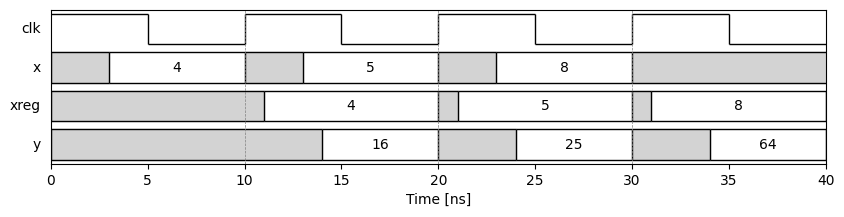

In [ ]:
# Create a clock signal
ncycles = 4
clk_period = 10
clk = ClkSig(clk_name="clk", period=clk_period, ncycles=ncycles)
p = clk.clk_periods()

# Input
xvals = ['x', '4', 'x', '5', 'x', '8', 'x']
xtimes = [0, 3, 10, 13, 20, 23, 30]
xsig = SigTimingInfo("x", xtimes, xvals)

# Registered value:  xreg <= x
xregvals = ['x', '4', 'x', '5', 'x', '8', 'x']
xregtimes = [0, 11, 20, 21, 30, 31, 40]
xregsig = SigTimingInfo("xreg", xregtimes, xregvals)

# Combinational output y = xreg*xreg
yvals = ['x', '16', 'x', '25', 'x', '64', 'x']
ytimes = [0, 14, 20, 24, 30, 34, 40]
ysig = SigTimingInfo("y", ytimes, yvals)


# Create the timing diagram
td = TimingDiagram()
td.add_signal(clk)
td.add_signals([xsig, xregsig, ysig])

# Plot and label the signals
ax = td.plot_signals(trange=[0,40])
_ = ax.set_xlabel("Time [ns]")

You can also highlight cells.  For example, below we highlight different values for a processign sequence.

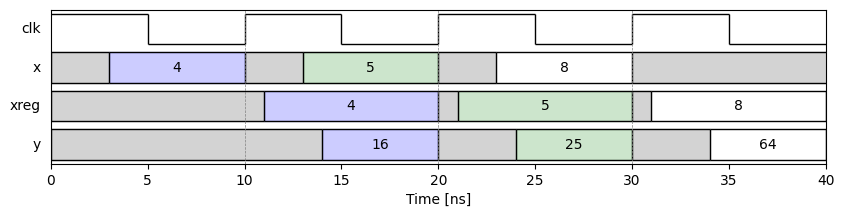

In [23]:
# Plot and label the signals
ax = td.plot_signals(trange=[0,40])
_ = ax.set_xlabel("Time [ns]")

colors = ['blue', 'green']
sigs = ['x', 'xreg', 'y']
for i, color in enumerate(colors):
    for s in sigs:
        td.add_patch(s, ind=i*2+1, color=color, alpha=0.2)